In [1]:
#Exploring the Data
import os

dataset_path = "archive"

# Count images in each class
for split in ["Training", "Testing"]:
    print(f"\n {split}:")
    for class_name in os.listdir(os.path.join(dataset_path, split)):
        class_path = os.path.join(dataset_path, split, class_name)
        count = len(os.listdir(class_path))
        print(f"   {class_name}: {count} images")


 Training:
   glioma: 1400 images
   meningioma: 1400 images
   notumor: 1400 images
   pituitary: 1400 images

 Testing:
   glioma: 400 images
   meningioma: 400 images
   notumor: 400 images
   pituitary: 400 images


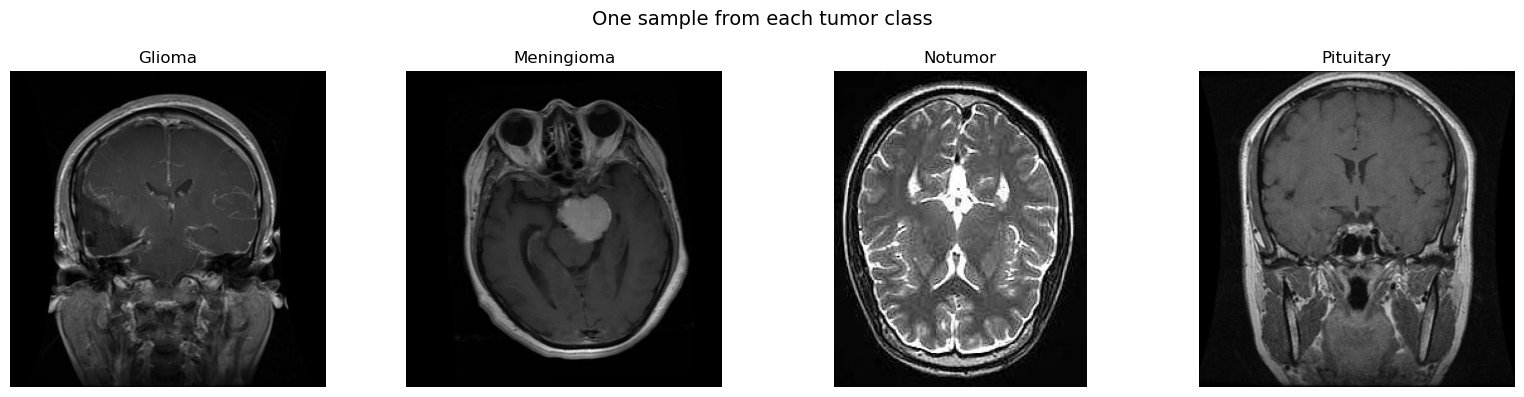

 Saved as sample_images.png


In [2]:
#Visualize sample Images
import matplotlib.pyplot as plt
from PIL import Image
import os

dataset_path = "archive"
classes = ["glioma", "meningioma", "notumor", "pituitary"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("One sample from each tumor class", fontsize=14)

for i, class_name in enumerate(classes):
    folder = os.path.join(dataset_path, "Training", class_name)
    img_file = os.listdir(folder)[0]  # take first image
    img = Image.open(os.path.join(folder, img_file)).convert("L")  # grayscale
    
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(class_name.capitalize())
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("sample_images.png")
plt.show()
print(" Saved as sample_images.png")

In [3]:
# Load and Prepare all Images
import numpy as np
from PIL import Image
import os

def load_dataset(split, img_size=64):
    """Load all images from Training or Testing folder"""
    classes = ["glioma", "meningioma", "notumor", "pituitary"]
    X, y = [], []
    
    for label, class_name in enumerate(classes):
        folder = os.path.join("archive", split, class_name)
        print(f"Loading {split}/{class_name}...")
        
        for img_file in os.listdir(folder):
            img_path = os.path.join(folder, img_file)
            try:
                img = Image.open(img_path).convert("L")        # grayscale
                img = img.resize((img_size, img_size))          # resize to 64x64
                img_array = np.array(img) / 255.0               # normalize 0-1
                X.append(img_array.flatten())                   # flatten to 1D
                y.append(label)
            except:
                pass  # skip corrupted files
    
    return np.array(X), np.array(y)

# Load both splits
print("Loading training data...")
X_train, y_train = load_dataset("Training")

print("\nLoading testing data...")
X_test, y_test = load_dataset("Testing")

print(f"\n Training set: {X_train.shape}")
print(f" Testing set:  {X_test.shape}")

Loading training data...
Loading Training/glioma...
Loading Training/meningioma...
Loading Training/notumor...
Loading Training/pituitary...

Loading testing data...
Loading Testing/glioma...
Loading Testing/meningioma...
Loading Testing/notumor...
Loading Testing/pituitary...

 Training set: (5600, 4096)
 Testing set:  (1600, 4096)


In [4]:
#Train the Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

print("Training model... (this takes ~1-2 minutes)")
start = time.time()

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

end = time.time()
print(f" Training done in {end-start:.1f} seconds")

# Evaluate
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f" Test Accuracy: {accuracy*100:.2f}%")

Training model... (this takes ~1-2 minutes)
 Training done in 4.3 seconds
 Test Accuracy: 87.19%


              precision    recall  f1-score   support

      glioma       0.94      0.66      0.78       400
  meningioma       0.82      0.88      0.85       400
     notumor       0.83      1.00      0.91       400
   pituitary       0.93      0.95      0.94       400

    accuracy                           0.87      1600
   macro avg       0.88      0.87      0.87      1600
weighted avg       0.88      0.87      0.87      1600



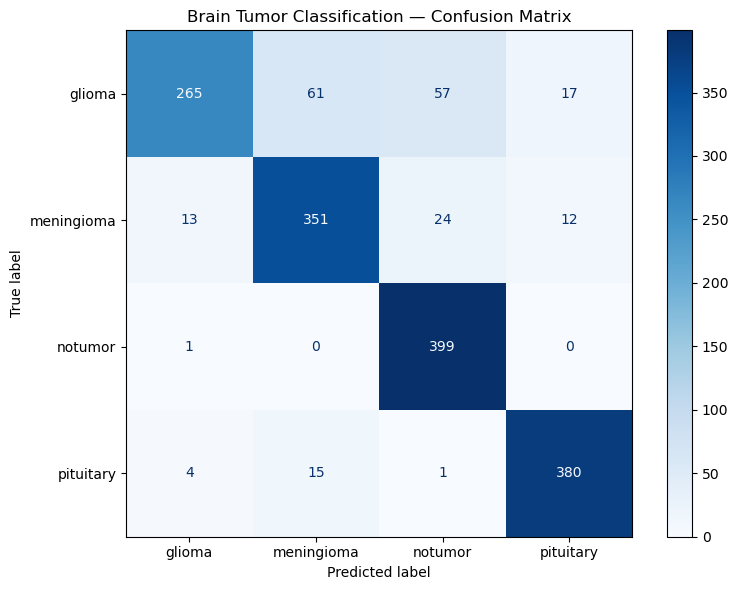

 Saved as confusion_matrix.png


In [5]:
#Full Result Report
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

classes = ["glioma", "meningioma", "notumor", "pituitary"]

# Text report
print(classification_report(y_test, y_pred, target_names=classes))

# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=classes,
    cmap="Blues",
    ax=ax
)
plt.title("Brain Tumor Classification — Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()
print(" Saved as confusion_matrix.png")